In [2]:
from networkx.readwrite import json_graph
from scipy.stats import percentileofscore
from traceback import format_exception
import cProfile
import json
import networkx as nx
import numpy as np
import pandas as pd
import pstats
import random
import sys
import nxneo4j as nx4
from neo4j import GraphDatabase
import matplotlib.pyplot as plt
import io

In [2]:
DEBUG = False # True

In [3]:

######################################################################
## disparity filter for extracting the multiscale backbone of
## complex weighted networks

def get_nes (graph, label):
    """
    find the neighborhood attention set (NES) for the given label
    """
    for node_id in graph.nodes():
        node = graph.node[node_id]

        if node["label"].lower() == label:
            return set([node_id]).union(set([id for id in graph.neighbors(node_id)]))


def disparity_integral (x, k):
    """
    calculate the definite integral for the PDF in the disparity filter
    """
    assert x != 1.0, "x == 1.0"
    assert k != 1.0, "k == 1.0"
    return ((1.0 - x)**k) / ((k - 1.0) * (x - 1.0))


def get_disparity_significance (norm_weight, degree):
    """
    calculate the significance (alpha) for the disparity filter
    """
    return 1.0 - ((degree - 1.0) * (disparity_integral(norm_weight, degree) - disparity_integral(0.0, degree)))


def disparity_filter (graph):
    """
    implements a disparity filter, based on multiscale backbone networks
    https://arxiv.org/pdf/0904.2389.pdf
    """
    alpha_measures = []

    for node_id in graph.nodes():
        node = graph.nodes[node_id]
        degree = graph.degree(node_id)
        strength = 0.0

        for id0, id1 in graph.edges(nbunch=[node_id]):
            edge = graph[id0][id1]
            strength += edge["weight"]

        node["strength"] = strength

        for id0, id1 in graph.edges(nbunch=[node_id]):
            edge = graph[id0][id1]

            norm_weight = edge["weight"] / strength
            edge["norm_weight"] = norm_weight

            if degree > 1:
                try:
                    if norm_weight == 1.0:
                        norm_weight -= 0.0001

                    alpha = get_disparity_significance(norm_weight, degree)
                except AssertionError:
                    report_error("disparity {}".format(repr(node)), fatal=True)

                edge["alpha"] = alpha
                alpha_measures.append(alpha)
            else:
                edge["alpha"] = 0.0

    for id0, id1 in graph.edges():
        edge = graph[id0][id1]
        edge["alpha_ptile"] = percentileofscore(alpha_measures, edge["alpha"]) / 100.0

    return alpha_measures

def report_error (cause_string, logger=None, fatal=False):
    """
    TODO: errors should go to logger, and not be fatal
    """
    etype, value, tb = sys.exc_info()
    error_str = "{} {}".format(cause_string, str(format_exception(etype, value, tb, 3)))

    if logger:
        logger.info(error_str)
    else:
        print(error_str)

    if fatal:
        sys.exit(-1)

In [4]:
######################################################################
## related metrics

def calc_centrality (graph, min_degree=1):
    """
    to conserve compute costs, ignore centrality for nodes below `min_degree`
    """
    sub_graph = graph.copy()
    sub_graph.remove_nodes_from([ n for n, d in list(graph.degree) if d < min_degree ])

    centrality = nx.betweenness_centrality(sub_graph, weight="weight")
    #centrality = nx.closeness_centrality(sub_graph, distance="distance")

    return centrality


def calc_quantiles (metrics, num):
    """
    calculate `num` quantiles for the given list
    """
    global DEBUG

    bins = np.linspace(0, 1, num=num, endpoint=True)
    s = pd.Series(metrics)
    q = s.quantile(bins, interpolation="nearest")

    try:
        dig = np.digitize(metrics, q) - 1
    except ValueError as e:
        print("ValueError:", str(e), metrics, s, q, bins)
        sys.exit(-1)

    quantiles = []

    for idx, q_hi in q.items():
        quantiles.append(q_hi)

        if DEBUG:
            print(idx, q_hi)

    return quantiles


def calc_alpha_ptile (alpha_measures, show=True):
    """
    calculate the quantiles used to define a threshold alpha cutoff
    """
    quantiles = calc_quantiles(alpha_measures, num=10)
    num_quant = len(quantiles)

    if show:
        print("\tptile\talpha")

        for i in range(num_quant):
            percentile = i / float(num_quant)
            print("\t{:0.2f}\t{:0.4f}".format(percentile, quantiles[i]))

    return quantiles, num_quant


def cut_graph (graph, min_alpha_ptile=0.5, min_degree=2):
    """
    apply the disparity filter to cut the given graph
    """
    filtered_set = set([])

    for id0, id1 in graph.edges():
        edge = graph[id0][id1]

        if edge["alpha_ptile"] < min_alpha_ptile:
            filtered_set.add((id0, id1))

    for id0, id1 in filtered_set:
        graph.remove_edge(id0, id1)

    filtered_set = set([])

    for node_id in graph.nodes():
        node = graph.nodes[node_id]

        if graph.degree(node_id) < min_degree:
            filtered_set.add(node_id)

    for node_id in filtered_set:
        graph.remove_node(node_id)

In [5]:


######################################################################
## profiling utilities




def start_profiling ():
    """start profiling"""
    pr = cProfile.Profile()
    pr.enable()

    return pr


def stop_profiling (pr):
    """stop profiling and report"""
    pr.disable()

    s = io.StringIO()
    sortby = "cumulative"
    ps = pstats.Stats(pr, stream=s).sort_stats(sortby)

    ps.print_stats()
    print(s.getvalue())


def report_error (cause_string, logger=None, fatal=False):
    """
    TODO: errors should go to logger, and not be fatal
    """
    etype, value, tb = sys.exc_info()
    error_str = "{} {}".format(cause_string, str(format_exception(etype, value, tb, 3)))

    if logger:
        logger.info(error_str)
    else:
        print(error_str)

    if fatal:
        sys.exit(-1)

In [6]:

######################################################################
## graph serialization

def load_graph (graph_path):
    """
    load a graph from JSON
    """
    with open(graph_path) as f:
        data = json.load(f)
        graph = json_graph.node_link_graph(data, directed=True)
        return graph


def save_graph (graph, graph_path):
    """
    save a graph as JSON
    """
    with open(graph_path, "w") as f:
        data = json_graph.node_link_data(graph)
        json.dump(data, f)




In [104]:
######################################################################
## testing

def random_graph (n, k, seed=0):
    """
    populate a random graph (with an optional seed) with `n` nodes and
    up to `k` edges for each node
    """
    graph = nx.DiGraph()
    random.seed(seed)

    for node_id in range(n):
        graph.add_node(node_id, label=str(node_id))

    for node_id in range(n):
        population = set(range(n)) - set([node_id])

        for neighbor in random.sample(population, random.randint(0, k)):
            weight = random.random()
            graph.add_edge(node_id, neighbor, weight=weight)

    return graph


def describe_graph (graph, min_degree=1, show_centrality=False):
    """
    describe a graph
    """
    print("\ngraph: {} nodes {} edges\n".format(len(graph.nodes()), len(graph.edges())))

    if show_centrality:
        print(calc_centrality(graph, min_degree))

def toy_graph():
    # Load data from Excel
    nodes_df = pd.read_excel('C:/buildbr/big-cities-transport/04.Disparity/toy_nx.xlsx', sheet_name='Nodes')
    edges_df = pd.read_excel('C:/buildbr/big-cities-transport/04.Disparity/toy_nx.xlsx', sheet_name='Edges')

    # Create a NetworkX graph
    G = nx.DiGraph()

    # Add nodes with attributes
    for _, row in nodes_df.iterrows():
        node_label = row['Node']
        degree = row['Degree']
        attributes = {key: row[key] for key in row.keys() if key not in ['Node', 'Degree']}
        G.add_node(node_label, degree=degree, **attributes)  # Add other node attributes

    # Add edges with attributes
    for _, row in edges_df.iterrows():
        source = row['Source']
        target = row['Target']
        weight = row['Distress']
        edge_attributes = {key: row[key] for key in row.keys() if key not in ['Source', 'Target', 'Distress']}
        G.add_edge(source, target, weight=weight, **edge_attributes)    
    return G


def print_toy(G):
    pos = {}
    for node in G.nodes():
        pos[node] = (G.nodes[node]['long'], G.nodes[node]['lat'])

    fig, ax = plt.subplots()
    nx.draw_networkx_nodes(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    curved_edges = [edge for edge in G.edges() if reversed(edge) in G.edges()]
    straight_edges = list(set(G.edges()) - set(curved_edges))
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=straight_edges)
    arc_rad = 0.08
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=curved_edges, connectionstyle=f'arc3, rad = {arc_rad}')
    plt.show()
    
def rank_edges(G):
    
    # # Normal Ranking
    # print("\n Weight rank ")
    alpha_sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    # for edge in alpha_sorted_edges:
    #     print(f"({edge[0]} - {int(edge[1])}) | alpha: {edge[2]['alpha_ptile']} | weight: {edge[2]['weight']} ")
        
    # print("\n Alpha rank ")
    normal_sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['alpha_ptile'], reverse=True)
    # for edge in normal_sorted_edges:
    #     print(f"({edge[0]} - {int(edge[1])}) | alpha: {edge[2]['alpha_ptile']} | weight: {edge[2]['weight']} ")

    # Combine ranks into a single table
    combined_edges = sorted(G.edges(data=True), key=lambda x: (x[2]['alpha_ptile'], x[2]['weight'],), reverse=True)

    # Calculate rank positions
    alpha_positions = {}
    alpha_sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['alpha_ptile'], reverse=True)
    for idx, edge in enumerate(alpha_sorted_edges):
        alpha_positions[edge]: idx + 1 

    weight_positions = {}
    weight_sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    for idx, edge in enumerate(weight_sorted_edges):
        weight_positions[edge]: idx + 1 

    print(alpha_sorted_edges)
    

    print("\n Combined Rank ")
    for edge in combined_edges:
        print(f"alpha: {round(edge[2]['alpha_ptile'],3)} ()| weight: {round(edge[2]['weight'],3)} () | ({edge[0]} - {int(edge[1])}) ")




    # Calculate Kendall ranking metric
    weight_rank = [edge[2]['weight'] for edge in combined_edges]
    alpha_rank = [edge[2]['alpha_ptile'] for edge in combined_edges]

    
    kendall_metric = kendall_tau_rank_correlation(weight_rank, alpha_rank)
    print(f"\n Kendall Ranking Metric: {kendall_metric}")

# Calculate Kendall ranking metric
def kendall_tau_rank_correlation(rank1, rank2):
    concordant_pairs = 0
    discordant_pairs = 0

    for i in range(len(rank1)):
        for j in range(i + 1, len(rank1)):
            if (rank1[i], rank1[j]) < (rank2[i], rank2[j]):
                concordant_pairs += 1
            else:
                discordant_pairs += 1

    return (concordant_pairs - discordant_pairs) / (concordant_pairs + discordant_pairs)
   


def main (n=10, k=2, min_alpha_ptile=0.5, min_degree=2):
    # # generate a random graph (from seed, always the same)    
    # graph = toy_graph()
    # save_graph(graph, "toy.json")

    # import
    graph = load_graph("C:/buildbr/big-cities-transport/04.Disparity/toy.json")

    # Original Grapg
    describe_graph(graph, min_degree)
    print_toy(graph)      

    # calculate the multiscale backbone metrics
    alpha_measures = disparity_filter(graph)
    # disparity and normal ranks
    rank_edges(graph)

    
    
    # quantiles, num_quant = calc_alpha_ptile(alpha_measures)
    
    # alpha_cutoff = quantiles[round(num_quant * min_alpha_ptile)]

    # print("\nfilter: percentile {:0.2f}, min alpha {:0.4f}, min degree {}".format(
    #         min_alpha_ptile, alpha_cutoff, min_degree
    #         ))

    # # apply the filter to cut the graph
    # cut_graph(graph, min_alpha_ptile, min_degree)

    # save_graph(graph, "h.json")
    # describe_graph(graph, min_degree)
    # print_toy(graph)



In [9]:
def normalize_values_within_day(input_dict):
    normalized_dict = {}
    for od_key, od_value in input_dict.items():
        normalized_dict[od_key] = {}
        for day_key, day_value in od_value.items():
            normalized_dict[od_key][day_key] = {}
            # Find the minimum and maximum values within the current day
            min_value = min(day_value.values())
            max_value = max(day_value.values())
            # Normalize the values within the current day
            normalized_dict[od_key][day_key] = {k: (v - min_value) / (max_value - min_value) for k, v in day_value.items()}
    return normalized_dict

# Your initial dictionary
edge = {
    'od1': {
        'sun': {
            'a': 5,
            'b': 6,
            'c': 7,
            'd': 8
        },
        'sat': {
            'a': 5,
            'b': 6,
            'c': 7,
            'd': 8
        }
    },
    'od2': {
        'sun': {
            'a': 5,
            'b': 6,
            'c': 7,
            'd': 8
        },
        'sat': {
            'a': 5,
            'b': 6,
            'c': 7,
            'd': 8
        }
    }
}

# Normalize the values of 'a', 'b', 'c', and 'd' across all sub-dictionaries
normalized_edge = normalize_values_within_day(edge)

# Print the normalized dictionary
print(normalized_edge)

{'od1': {'sun': {'a': 0.0, 'b': 0.3333333333333333, 'c': 0.6666666666666666, 'd': 1.0}, 'sat': {'a': 0.0, 'b': 0.3333333333333333, 'c': 0.6666666666666666, 'd': 1.0}}, 'od2': {'sun': {'a': 0.0, 'b': 0.3333333333333333, 'c': 0.6666666666666666, 'd': 1.0}, 'sat': {'a': 0.0, 'b': 0.3333333333333333, 'c': 0.6666666666666666, 'd': 1.0}}}



graph: 6 nodes 12 edges



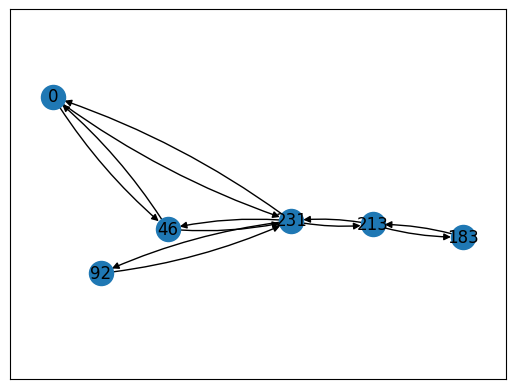

[(231, 213.0, {'weight': 0.0829928511150512, 'norm_weight': 0.12731319337950467, 'alpha': 0.3854862326081603, 'alpha_ptile': 1.0}), (231, 0.0, {'weight': 0.1005991746832244, 'norm_weight': 0.15432175191221006, 'alpha': 0.3093400283022658, 'alpha_ptile': 0.9166666666666667}), (213, 183.0, {'weight': 0.0835067049586939, 'norm_weight': 0.35475608697128497, 'alpha': 0.2686406618878743, 'alpha_ptile': 0.8333333333333335}), (46, 0.0, {'weight': 0.1019107434000816, 'norm_weight': 0.3734327889296771, 'alpha': 0.24598180960460148, 'alpha_ptile': 0.75}), (0, 231.0, {'weight': 0.0816813518425639, 'norm_weight': 0.4449066923856898, 'alpha': 0.17104011273051367, 'alpha_ptile': 0.6666666666666667}), (231, 46.0, {'weight': 0.1671970173871082, 'norm_weight': 0.2564845757325827, 'alpha': 0.12561163741135695, 'alpha_ptile': 0.5833333333333334}), (0, 46.0, {'weight': 0.1019107434000815, 'norm_weight': 0.5550933076143101, 'alpha': 0.0880657049011414, 'alpha_ptile': 0.5}), (46, 231.0, {'weight': 0.17099176

In [105]:
######################################################################
## main entry point

if __name__ == "__main__":
    main()
    